In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("sampled_reviews.csv")
display(df.head(15))

,_id,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,category,class
0,{'$oid': '5a132768741a2384e847b8ed'},A2PAVURT4NOHE1,0000031852,Leah,"[0, 0]",Bought it for a ballet tutu but it is being wo...,5.0,Super cute,1388361600,"12 30, 2013",Sports_and_Outdoors,1.0
1,{'$oid': '5a132768741a2384e847b8e9'},A1SNLWGLFXD70K,0000031852,DEVA,"[0, 0]",I origonally didn't get the item I ordered. W...,4.0,Happy with purchase even though it came a lot ...,1392940800,"02 21, 2014",Sports_and_Outdoors,1.0
2,{'$oid': '5a132768741a2384e847b8ee'},A3URQ0LXLV46E9,0000031852,shortyvee,"[0, 0]",My daughter and her friends love the colors an...,4.0,zebralisous,1400544000,"05 20, 2014",Sports_and_Outdoors,1.0
3,{'$oid': '5a132768741a2384e847b8ea'},A1KJ4CVG87QW09,0000031852,Donna Carter-Scott,"[0, 0]","Arrived very timely, cute grandbaby loves it. ...",4.0,Cute Tutu,1389657600,"01 14, 2014",Sports_and_Outdoors,1.0
4,{'$oid': '5a132768741a2384e847b8eb'},AA9ITO6ZLZW6,0000031852,Jazzy77,"[0, 0]",My little girl just loves to wear this tutu be...,5.0,Versatile,1399507200,"05 8, 2014",Sports_and_Outdoors,1.0
5,{'$oid': '5a132768741a2384e847b8ec'},APJ5ULJ1RMZ4,0000031852,kesha wallace,"[0, 0]",I bought this for my 3 yr old daughter when I ...,1.0,Would not recommend,1398556800,"04 27, 2014",Sports_and_Outdoors,0.0
6,{'$oid': '5a132768741a2384e847b8f0'},A2EPSZKEG06QZE,0000031895,Katie R.,"[1, 1]",This tutu is completely see-through. I bought ...,2.0,Completely See-Through,1396224000,"03 31, 2014",Sports_and_Outdoors,0.0
7,{'$oid': '5a132768741a2384e847b8f1'},A23K73OVXJ04EG,0000031895,"Susie Mo ""author""","[0, 0]",It was as described and fit my 6 year old gran...,5.0,Neon Blue Tutu,1391212800,"02 1, 2014",Sports_and_Outdoors,1.0
8,{'$oid': '5a132768741a2384e847b8f4'},A9A1P7C3G1V9H,0000031909,michelle smith,"[0, 0]","Cheap fabric, it ripped the same day my daught...",2.0,Two Stars,1404950400,"07 10, 2014",Sports_and_Outdoors,0.0
9,{'$oid': '5a132768741a2384e847b8f2'},A2182SHKEJLY7N,0000031909,Delta Pruim,"[0, 0]","It's a really nice tutu, but there was one pro...",4.0,"Nice, but one problem",1384041600,"11 10, 2013",Sports_and_Outdoors,1.0


In [6]:
print(df.isna().sum())

_id                 0
reviewerID          0
asin                0
reviewerName      811
helpful             0
reviewText          0
overall             0
summary             4
unixReviewTime      0
reviewTime          0
category            0
class               0
dtype: int64


In [7]:
display(df[['summary','reviewText']])
df = df.drop(columns= ["_id","helpful"])

,summary,reviewText
0,Super cute,Bought it for a ballet tutu but it is being wo...
1,Happy with purchase even though it came a lot ...,I origonally didn't get the item I ordered. W...
2,zebralisous,My daughter and her friends love the colors an...
3,Cute Tutu,"Arrived very timely, cute grandbaby loves it. ..."
4,Versatile,My little girl just loves to wear this tutu be...
...,...,...
199995,Well worth it,It is as easy as it looks. Came in handy at a...
199996,perfect temp is well made,Went hunting in a two person tent. It was abou...
199997,Takes the edge off cold mornings,"For what it is, it works OK. Was hoping it wo..."
199998,Low heat output is just what I needed,I needed something to heat my small pump house...


In [8]:
print(df.columns)
# print(df.info())
# print(df.duplicated().sum())
print(df['unixReviewTime'].duplicated().sum())

Index(['reviewerID', 'asin', 'reviewerName', 'reviewText', 'overall',
       'summary', 'unixReviewTime', 'reviewTime', 'category', 'class'],
      dtype='object')
195261


In [39]:
df = df.dropna(subset=['summary'])
print(df.isna().sum())
df.to_csv("cleaned.csv")

reviewerID          0
asin                0
reviewerName      811
reviewText          0
overall             0
summary             0
unixReviewTime      0
reviewTime          0
category            0
class               0
review_length       0
review_date         0
dtype: int64


In [45]:
display(df.nunique())
display(df.count())
display(df[df['class']==0].count())
display(df[df['class']==1].count())

reviewerID        182901
asin               15207
reviewerName      153514
reviewText        199823
overall                5
summary           144131
unixReviewTime      4739
reviewTime          4739
category               1
class                  2
dtype: int64

reviewerID        199996
asin              199996
reviewerName      199185
reviewText        199996
overall           199996
summary           199996
unixReviewTime    199996
reviewTime        199996
category          199996
class             199996
dtype: int64

reviewerID        34035
asin              34035
reviewerName      33906
reviewText        34035
overall           34035
summary           34035
unixReviewTime    34035
reviewTime        34035
category          34035
class             34035
dtype: int64

reviewerID        165961
asin              165961
reviewerName      165279
reviewText        165961
overall           165961
summary           165961
unixReviewTime    165961
reviewTime        165961
category          165961
class             165961
dtype: int64

##STAGE 2
EDA


In [10]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199996 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   reviewerID      199996 non-null  object 
 1   asin            199996 non-null  object 
 2   reviewerName    199185 non-null  object 
 3   reviewText      199996 non-null  object 
 4   overall         199996 non-null  float64
 5   summary         199996 non-null  object 
 6   unixReviewTime  199996 non-null  int64  
 7   reviewTime      199996 non-null  object 
 8   category        199996 non-null  object 
 9   class           199996 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 16.8+ MB


In [47]:
df.nunique().sort_values(ascending=False)

reviewText        199823
reviewerID        182901
reviewerName      153514
summary           144131
asin               15207
unixReviewTime      4739
reviewTime          4739
overall                5
class                  2
category               1
dtype: int64

class
1.0    82.98216
0.0    17.01784
Name: proportion, dtype: float64

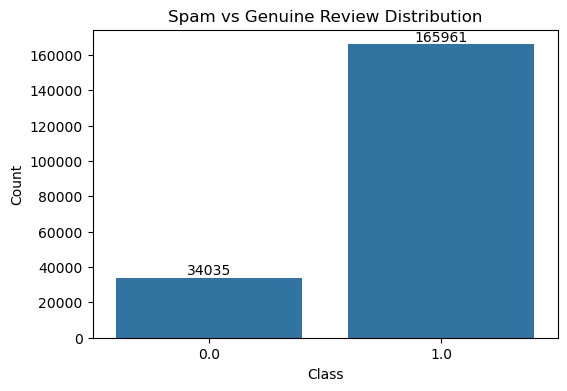

In [15]:
df['class'].value_counts()
display(df['class'].value_counts(normalize=True) * 100)
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)

plt.title('Spam vs Genuine Review Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

overall
1.0     12388
2.0      8352
3.0     13295
4.0     40008
5.0    125953
Name: count, dtype: int64

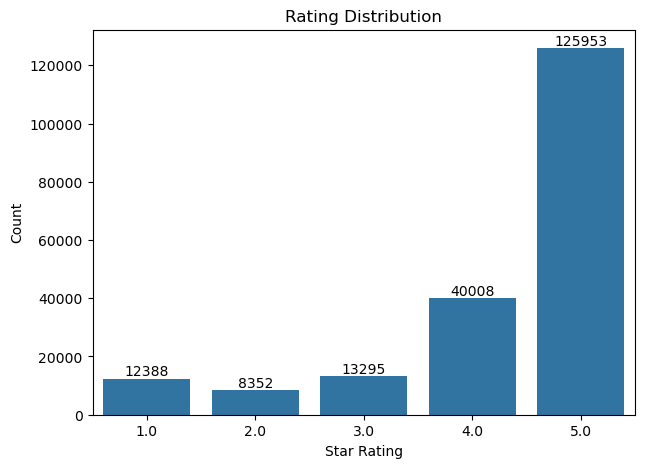

In [16]:
display(df['overall'].value_counts().sort_index())
plt.figure(figsize=(7,5))
sns.countplot(x='overall', data=df)

plt.title('Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Count')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

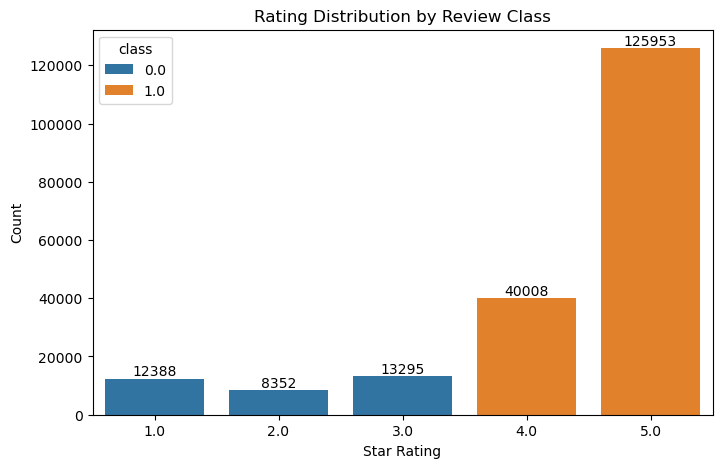

In [17]:
pd.crosstab(df['overall'], df['class'])
plt.figure(figsize=(8,5))
sns.countplot(x='overall', hue='class', data=df)

plt.title('Rating Distribution by Review Class')
plt.xlabel('Star Rating')
plt.ylabel('Count')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

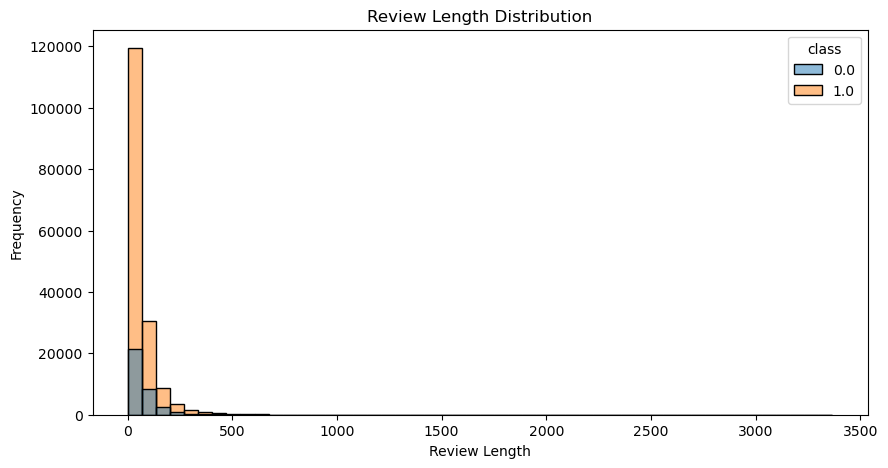

In [19]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
df['review_length'].describe()
df.groupby('class')['review_length'].mean()
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='review_length',
    hue='class',
    bins=50
)

plt.title('Review Length Distribution')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.show()

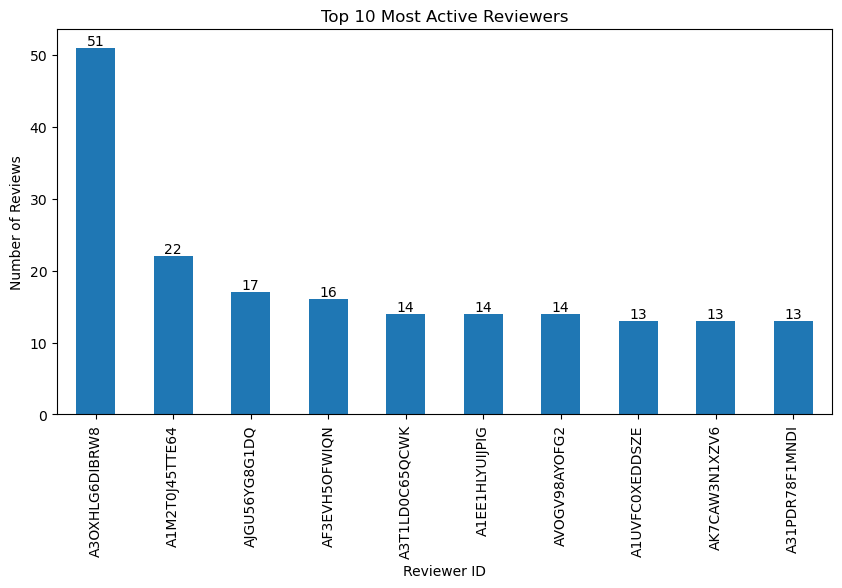

In [20]:
df['reviewText'].duplicated().sum()
df['reviewText'].value_counts().head(10)
reviewer_activity = df['reviewerID'].value_counts()

reviewer_activity.head(10)
plt.figure(figsize=(10,5))

reviewer_activity.head(10).plot(kind='bar')

plt.title('Top 10 Most Active Reviewers')
plt.xlabel('Reviewer ID')
plt.ylabel('Number of Reviews')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

In [22]:
product_reviews = df['asin'].value_counts()

product_reviews.head(10)

asin
B0000533G7    2112
7245456313    1940
B00005MOYK    1437
B00004YVAJ    1428
B0007VB4NE     967
B0009JKG9M     966
B0007IS6ZG     949
B0002TOZ1E     887
B0006AAS4M     863
B00065X222     788
Name: count, dtype: int64

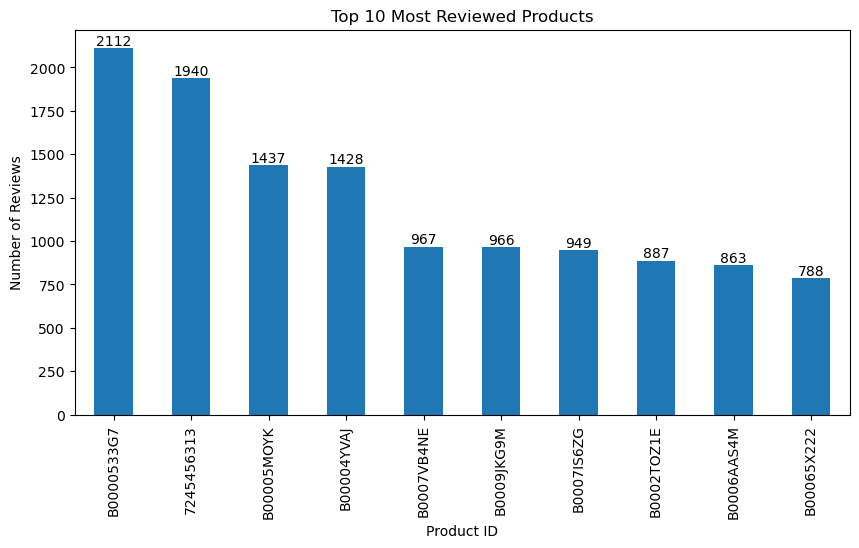

In [23]:
plt.figure(figsize=(10,5))

product_reviews.head(10).plot(kind='bar')

plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Product ID')
plt.ylabel('Number of Reviews')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

In [25]:
spam_products = df[df['class'] == 1]['asin'].value_counts()

spam_products.head(10)

asin
B0000533G7    1910
7245456313    1851
B00005MOYK    1348
B00004YVAJ    1343
B0009JKG9M     934
B0007VB4NE     791
B0002TOZ1E     755
B00065X222     751
B0007IS6ZG     727
B0000AY1W1     710
Name: count, dtype: int64

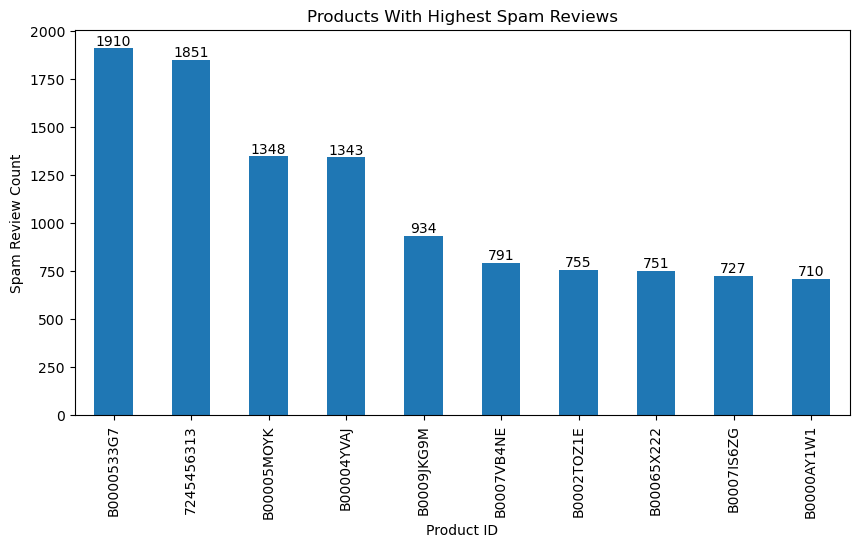

In [26]:
plt.figure(figsize=(10,5))

spam_products.head(10).plot(kind='bar')

plt.title('Products With Highest Spam Reviews')
plt.xlabel('Product ID')
plt.ylabel('Spam Review Count')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

In [29]:
from collections import Counter
import re

text = ' '.join(df['reviewText'].astype(str))

words = re.findall(r'\w+', text.lower())

word_counts = Counter(words)

word_counts.most_common(20)


[('the', 654243),
 ('i', 456972),
 ('and', 393290),
 ('it', 375740),
 ('a', 362512),
 ('to', 340274),
 ('is', 214592),
 ('for', 210413),
 ('this', 194176),
 ('of', 183092),
 ('in', 149110),
 ('my', 147315),
 ('that', 121471),
 ('you', 116858),
 ('on', 116268),
 ('with', 114825),
 ('but', 102559),
 ('have', 101875),
 ('was', 91954),
 ('not', 88044)]

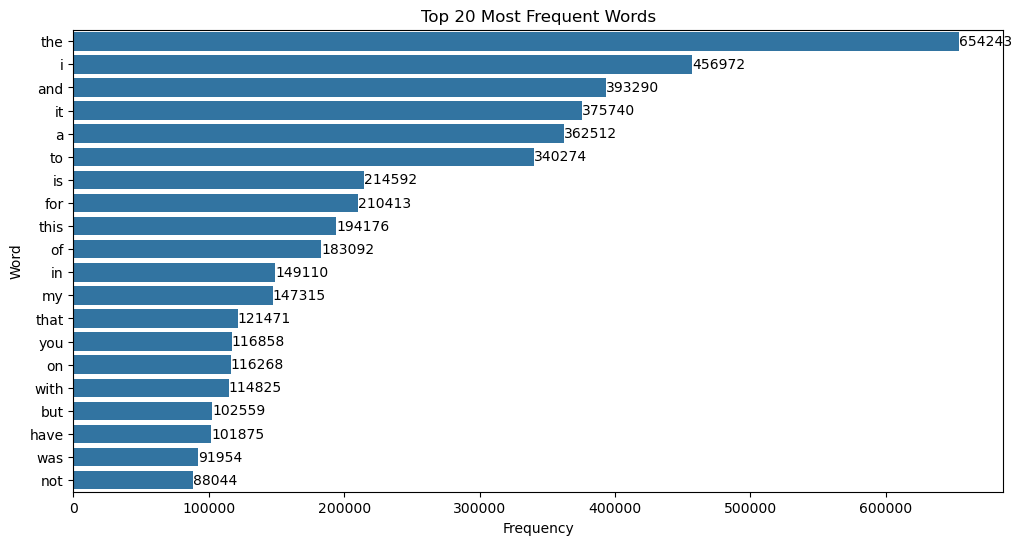

In [30]:
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['word', 'count']
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=common_words,
    x='count',
    y='word'
)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

In [32]:
df['review_date'] = pd.to_datetime(
    df['unixReviewTime'],
    unit='s'
)
df[['unixReviewTime', 'review_date']].head()

,unixReviewTime,review_date
0,1388361600,2013-12-30
1,1392940800,2014-02-21
2,1400544000,2014-05-20
3,1389657600,2014-01-14
4,1399507200,2014-05-08


In [33]:
monthly_reviews = df.set_index(
    'review_date'
).resample('ME').size()

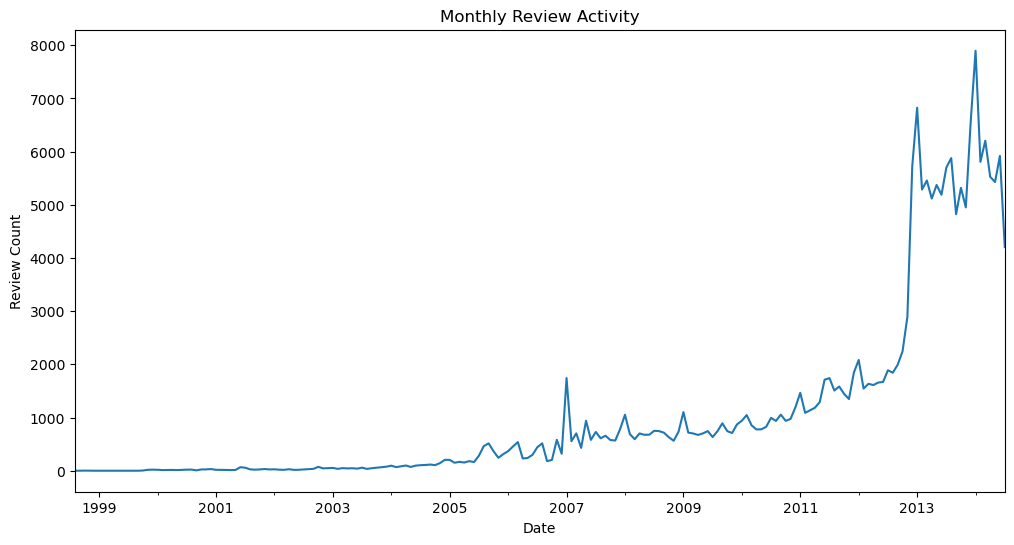

In [37]:
plt.figure(figsize=(12,6))

monthly_reviews.plot()

plt.title('Monthly Review Activity')
plt.xlabel('Date')
plt.ylabel('Review Count')
plt.show()